# TP - Optimisation lineaire avec PuLP (MEDIFAB)

## Objectifs
1. **Maximisation** : planifier le mix de production hebdomadaire pour maximiser la marge brute (3 variables entieres, 5 contraintes)
2. **Minimisation** : repartir les cycles de sterilisation entre 3 autoclaves pour minimiser la consommation energetique

## Contexte industriel
MEDIFAB produit 3 familles de dispositifs medicaux steriles.  
Chaque semaine, le planificateur doit decider combien de lots produire par ligne  
tout en respectant les contraintes de capacite, main d oeuvre et matieres premieres.

In [11]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print('PuLP version :', pulp.__version__)
print('Bibliotheques chargees.')

PuLP version : 3.3.2
Bibliotheques chargees.


---
## PARTIE 1 - Maximisation de la production (Integer Programming)

### Variables de decision (nombres entiers)
- `x1` = lots de Seringues steriles produits par semaine
- `x2` = lots de Poches de perfusion produits par semaine
- `x3` = lots de Dispositifs implantables produits par semaine

### Fonction objectif
Maximiser la marge brute : **Z = 420*x1 + 610*x2 + 890*x3** (en euros)

### 5 Contraintes
1. Autoclave : 3*x1 + 5*x2 + 8*x3 <= 120 h/semaine
2. Conditionnement : 2*x1 + 3*x2 + 4*x3 <= 80 h/semaine
3. Main d oeuvre : 4*x1 + 6*x2 + 9*x3 <= 160 h/semaine
4. Matieres premieres : 10*x1 + 18*x2 + 25*x3 <= 500 unites
5. Demande max client : x1 <= 15, x2 <= 10, x3 <= 6

In [12]:
# --- Definition du probleme ---
prob_max = pulp.LpProblem('MEDIFAB_Maximisation_Production', pulp.LpMaximize)

# Variables entieres positives
x1 = pulp.LpVariable('Seringues',     lowBound=0, cat='Integer')
x2 = pulp.LpVariable('Poches',        lowBound=0, cat='Integer')
x3 = pulp.LpVariable('Implantables',  lowBound=0, cat='Integer')

# Fonction objectif
prob_max += 420*x1 + 610*x2 + 890*x3, 'Marge_brute_totale'

# 5 Contraintes
prob_max += 3*x1 + 5*x2 + 8*x3 <= 120,  'C1_Autoclave_heures'
prob_max += 2*x1 + 3*x2 + 4*x3 <= 80,   'C2_Conditionnement_heures'
prob_max += 4*x1 + 6*x2 + 9*x3 <= 160,  'C3_Main_oeuvre_heures'
prob_max += 10*x1 + 18*x2 + 25*x3 <= 500, 'C4_Matieres_premieres'
prob_max += x1 <= 15,                    'C5a_Demande_max_Seringues'
prob_max += x2 <= 10,                    'C5b_Demande_max_Poches'
prob_max += x3 <= 6,                     'C5c_Demande_max_Implantables'

# Resolution
prob_max.solve(pulp.PULP_CBC_CMD(msg=0))

print('=== MAXIMISATION - Resultat ===')
print('Statut :', pulp.LpStatus[prob_max.status])
print()
print('Lots Seringues     (x1) :', int(pulp.value(x1)))
print('Lots Poches        (x2) :', int(pulp.value(x2)))
print('Lots Implantables  (x3) :', int(pulp.value(x3)))
print()
print('Marge brute totale : {:,.0f} EUR'.format(pulp.value(prob_max.objective)))
print()
print('--- Utilisation des ressources ---')
x1v, x2v, x3v = int(pulp.value(x1)), int(pulp.value(x2)), int(pulp.value(x3))
print('Autoclave       : {:5.1f} / 120 h  ({:.1f}%)'.format(3*x1v+5*x2v+8*x3v, (3*x1v+5*x2v+8*x3v)/120*100))
print('Conditionnement : {:5.1f} / 80  h  ({:.1f}%)'.format(2*x1v+3*x2v+4*x3v, (2*x1v+3*x2v+4*x3v)/80*100))
print('Main d oeuvre   : {:5.1f} / 160 h  ({:.1f}%)'.format(4*x1v+6*x2v+9*x3v, (4*x1v+6*x2v+9*x3v)/160*100))
print('Matieres prem.  : {:5.1f} / 500 u  ({:.1f}%)'.format(10*x1v+18*x2v+25*x3v, (10*x1v+18*x2v+25*x3v)/500*100))

=== MAXIMISATION - Resultat ===
Statut : Optimal

Lots Seringues     (x1) : 15
Lots Poches        (x2) : 10
Lots Implantables  (x3) : 3

Marge brute totale : 15,070 EUR

--- Utilisation des ressources ---
Autoclave       : 119.0 / 120 h  (99.2%)
Conditionnement :  72.0 / 80  h  (90.0%)
Main d oeuvre   : 147.0 / 160 h  (91.9%)
Matieres prem.  : 405.0 / 500 u  (81.0%)


## Graphiques - Maximisation

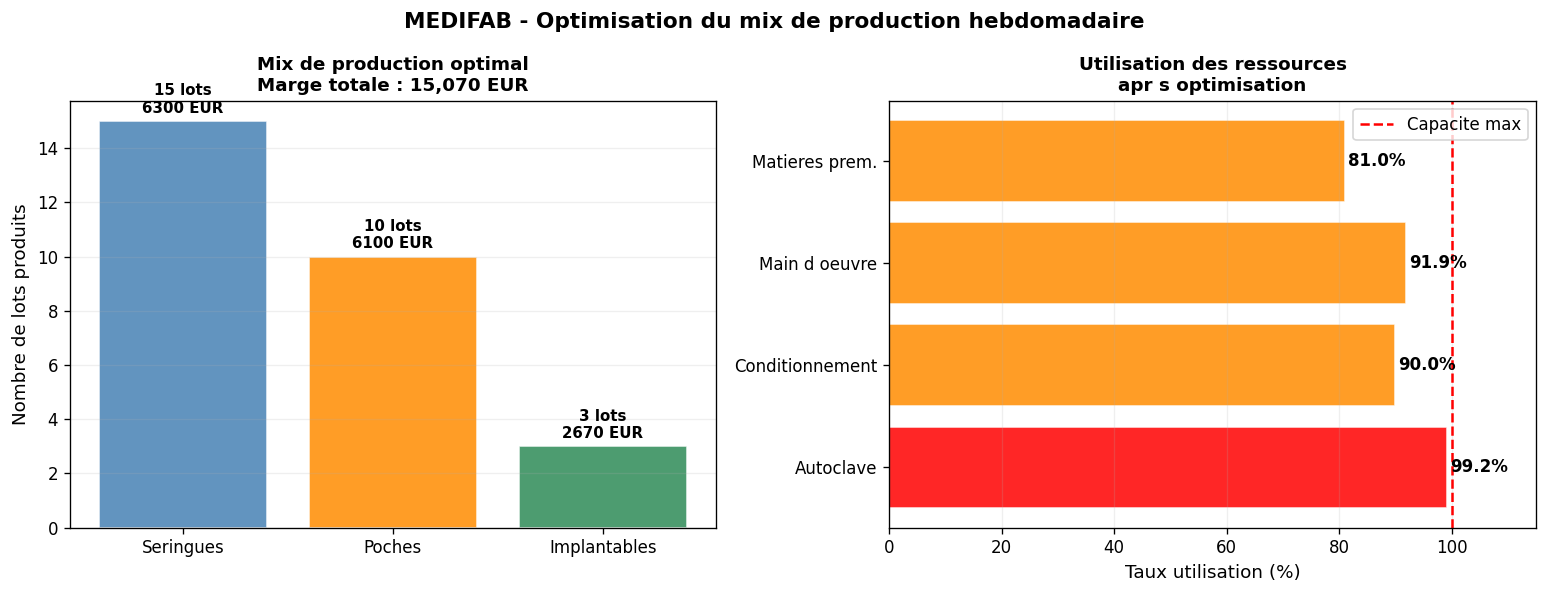

In [13]:
x1v, x2v, x3v = int(pulp.value(x1)), int(pulp.value(x2)), int(pulp.value(x3))
marge_totale = pulp.value(prob_max.objective)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : mix de production optimal
produits  = ['Seringues', 'Poches', 'Implantables']
lots      = [x1v, x2v, x3v]
marges_u  = [420, 610, 890]
marges_t  = [420*x1v, 610*x2v, 890*x3v]
colors    = ['steelblue', 'darkorange', 'seagreen']

bars = axes[0].bar(produits, lots, color=colors, alpha=0.85, edgecolor='white')
for bar, lot, m in zip(bars, lots, marges_t):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 str(lot)+' lots\n'+str(m)+' EUR', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Nombre de lots produits', fontsize=11)
axes[0].set_title('Mix de production optimal\nMarge totale : {:,.0f} EUR'.format(marge_totale),
                  fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.2, axis='y')

# Graphique 2 : taux d utilisation des ressources
ressources  = ['Autoclave', 'Conditionnement', 'Main d oeuvre', 'Matieres prem.']
utilisation = [
    (3*x1v+5*x2v+8*x3v)/120*100,
    (2*x1v+3*x2v+4*x3v)/80*100,
    (4*x1v+6*x2v+9*x3v)/160*100,
    (10*x1v+18*x2v+25*x3v)/500*100
]
col_util = ['red' if u >= 99 else 'darkorange' if u >= 80 else 'steelblue' for u in utilisation]
bars2 = axes[1].barh(ressources, utilisation, color=col_util, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, utilisation):
    axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 '{:.1f}%'.format(val), va='center', fontsize=10, fontweight='bold')
axes[1].axvline(100, color='red', linestyle='--', linewidth=1.5, label='Capacite max')
axes[1].set_xlim(0, 115)
axes[1].set_xlabel('Taux utilisation (%)', fontsize=11)
axes[1].set_title('Utilisation des ressources\napr s optimisation', fontsize=11, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis='x')

plt.suptitle('MEDIFAB - Optimisation du mix de production hebdomadaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimisation_maximisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PARTIE 2 - Minimisation de la consommation energetique

### Contexte
MEDIFAB dispose de 3 autoclaves d ages differents avec des consommations energetiques distinctes.  
L objectif est de repartir 50 cycles de sterilisation par semaine entre ces 3 machines  
pour minimiser la consommation electrique totale.

### Variables de decision
- `a1` = cycles sur Autoclave 1 (ancien, 18 kWh/cycle)
- `a2` = cycles sur Autoclave 2 (mi-age, 14 kWh/cycle)
- `a3` = cycles sur Autoclave 3 (recent, 11 kWh/cycle)

### Fonction objectif
Minimiser : **Z = 18*a1 + 14*a2 + 11*a3** (kWh/semaine)

### Contraintes
1. Quota minimum de cycles : a1 + a2 + a3 >= 50
2. Disponibilite A1 (maintenance 2j/sem) : a1 <= 20
3. Disponibilite A2 : a2 <= 30
4. Disponibilite A3 (machine neuve, priorite) : a3 <= 25
5. Equilibre charge : a1 >= 5 (maintien competences operateurs sur A1)

In [14]:
# --- Definition du probleme ---
prob_min = pulp.LpProblem('MEDIFAB_Minimisation_Energie', pulp.LpMinimize)

a1 = pulp.LpVariable('Autoclave_1_ancien',  lowBound=0, cat='Integer')
a2 = pulp.LpVariable('Autoclave_2_mi_age',  lowBound=0, cat='Integer')
a3 = pulp.LpVariable('Autoclave_3_recent',  lowBound=0, cat='Integer')

# Fonction objectif
prob_min += 18*a1 + 14*a2 + 11*a3, 'Consommation_kWh_totale'

# Contraintes
prob_min += a1 + a2 + a3 >= 50,  'C1_Quota_minimum_cycles'
prob_min += a1 <= 20,             'C2_Disponibilite_A1'
prob_min += a2 <= 30,             'C3_Disponibilite_A2'
prob_min += a3 <= 25,             'C4_Disponibilite_A3'
prob_min += a1 >= 5,              'C5_Equilibre_charge_operateurs'

# Resolution
prob_min.solve(pulp.PULP_CBC_CMD(msg=0))

a1v, a2v, a3v = int(pulp.value(a1)), int(pulp.value(a2)), int(pulp.value(a3))
kwh_total = pulp.value(prob_min.objective)
kwh_sans_optim = 18 * 50

print('=== MINIMISATION - Resultat ===')
print('Statut :', pulp.LpStatus[prob_min.status])
print()
print('Cycles sur Autoclave 1 (18 kWh) :', a1v)
print('Cycles sur Autoclave 2 (14 kWh) :', a2v)
print('Cycles sur Autoclave 3 (11 kWh) :', a3v)
print('Total cycles            :', a1v + a2v + a3v)
print()
print('Consommation optimisee  : {:,.0f} kWh/semaine'.format(kwh_total))
print('Consommation sans optim : {:,.0f} kWh/semaine (50 cycles sur A1)'.format(kwh_sans_optim))
print('Economie realisee       : {:,.0f} kWh/semaine ({:.1f}%)'.format(
    kwh_sans_optim - kwh_total, (kwh_sans_optim - kwh_total)/kwh_sans_optim*100))
print('Economie annuelle       : {:,.0f} kWh/an (52 semaines)'.format(
    (kwh_sans_optim - kwh_total) * 52))

=== MINIMISATION - Resultat ===
Statut : Optimal

Cycles sur Autoclave 1 (18 kWh) : 5
Cycles sur Autoclave 2 (14 kWh) : 20
Cycles sur Autoclave 3 (11 kWh) : 25
Total cycles            : 50

Consommation optimisee  : 645 kWh/semaine
Consommation sans optim : 900 kWh/semaine (50 cycles sur A1)
Economie realisee       : 255 kWh/semaine (28.3%)
Economie annuelle       : 13,260 kWh/an (52 semaines)


## Graphiques - Minimisation

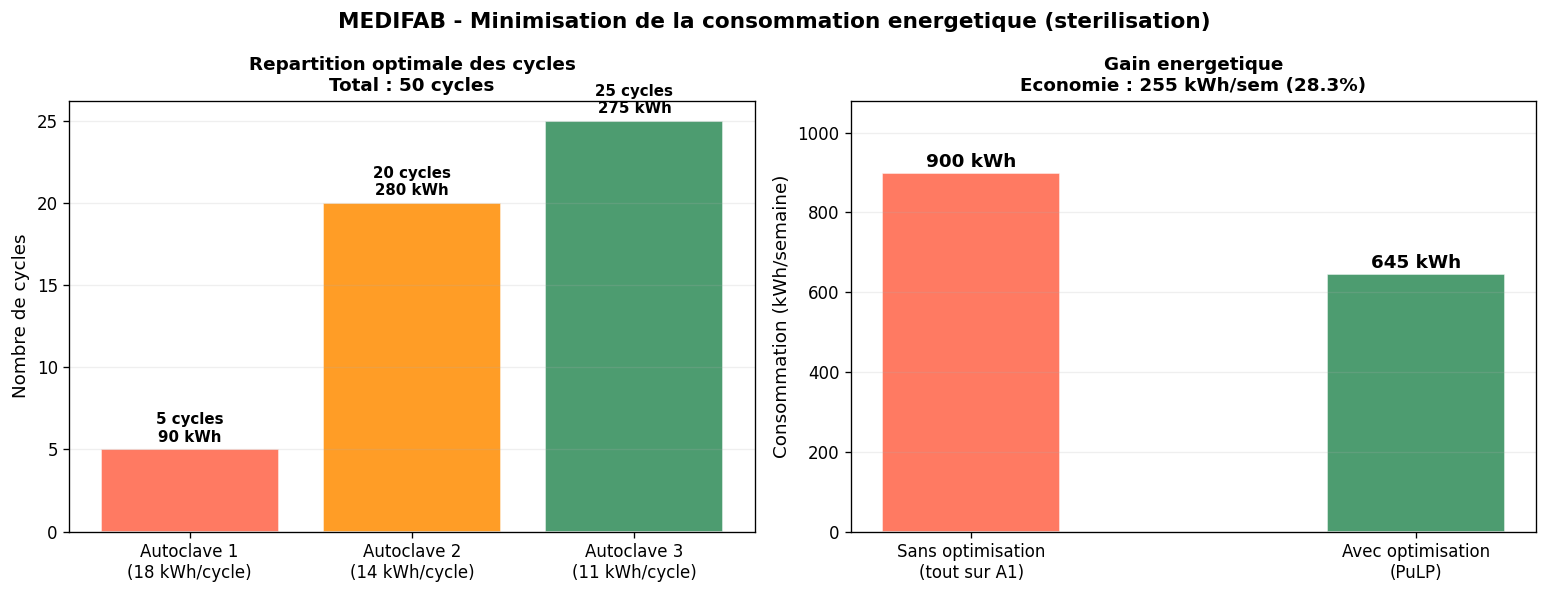

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : repartition des cycles
autoclaves = ['Autoclave 1\n(18 kWh/cycle)', 'Autoclave 2\n(14 kWh/cycle)', 'Autoclave 3\n(11 kWh/cycle)']
cycles     = [a1v, a2v, a3v]
kwh_par    = [18*a1v, 14*a2v, 11*a3v]
colors_ac  = ['tomato', 'darkorange', 'seagreen']

bars = axes[0].bar(autoclaves, cycles, color=colors_ac, alpha=0.85, edgecolor='white')
for bar, c, k in zip(bars, cycles, kwh_par):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(c)+' cycles\n'+str(k)+' kWh', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Nombre de cycles', fontsize=11)
axes[0].set_title('Repartition optimale des cycles\nTotal : '+str(a1v+a2v+a3v)+' cycles',
                  fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.2, axis='y')

# Graphique 2 : comparaison avant / apres optimisation
labels    = ['Sans optimisation\n(tout sur A1)', 'Avec optimisation\n(PuLP)']
kwh_vals  = [kwh_sans_optim, kwh_total]
col_comp  = ['tomato', 'seagreen']
bars2 = axes[1].bar(labels, kwh_vals, color=col_comp, alpha=0.85, edgecolor='white', width=0.4)
for bar, val in zip(bars2, kwh_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 '{:,.0f} kWh'.format(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Consommation (kWh/semaine)', fontsize=11)
axes[1].set_title('Gain energetique\nEconomie : {:,.0f} kWh/sem ({:.1f}%)'.format(
    kwh_sans_optim-kwh_total, (kwh_sans_optim-kwh_total)/kwh_sans_optim*100),
    fontsize=11, fontweight='bold')
axes[1].set_ylim(0, kwh_sans_optim * 1.2)
axes[1].grid(True, alpha=0.2, axis='y')

plt.suptitle('MEDIFAB - Minimisation de la consommation energetique (sterilisation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimisation_minimisation.png', dpi=150, bbox_inches='tight')
plt.show()

## Tableau de synthese comparatif

In [16]:
synthese = pd.DataFrame([
    {'Critere': 'Type de probleme',     'Maximisation':  'Mix de production',         'Minimisation': 'Repartition energetique'},
    {'Critere': 'Nombre de variables',  'Maximisation':  '3 (x1, x2, x3)',            'Minimisation': '3 (a1, a2, a3)'},
    {'Critere': 'Nombre de contraintes','Maximisation':  '5',                          'Minimisation': '5'},
    {'Critere': 'Type de variables',    'Maximisation':  'Entiers (Integer)',          'Minimisation': 'Entiers (Integer)'},
    {'Critere': 'Statut',               'Maximisation':  pulp.LpStatus[prob_max.status], 'Minimisation': pulp.LpStatus[prob_min.status]},
    {'Critere': 'Valeur optimale',      'Maximisation':  '{:,.0f} EUR/semaine'.format(pulp.value(prob_max.objective)),
                                         'Minimisation': '{:,.0f} kWh/semaine'.format(kwh_total)},
    {'Critere': 'Benefice principal',   'Maximisation':  'Marge maximisee',           'Minimisation': 'Economie {:,.0f} kWh/an'.format((kwh_sans_optim-kwh_total)*52)},
])

print('=== Synthese des deux optimisations ===')
print(synthese.to_string(index=False))

=== Synthese des deux optimisations ===
              Critere       Maximisation            Minimisation
     Type de probleme  Mix de production Repartition energetique
  Nombre de variables     3 (x1, x2, x3)          3 (a1, a2, a3)
Nombre de contraintes                  5                       5
    Type de variables  Entiers (Integer)       Entiers (Integer)
               Statut            Optimal                 Optimal
      Valeur optimale 15,070 EUR/semaine         645 kWh/semaine
   Benefice principal    Marge maximisee  Economie 13,260 kWh/an


## Conclusion et valeur metier

### Maximisation de la production
- PuLP trouve le mix optimal en quelques millisecondes, la ou un planificateur humain testerait manuellement
- La programmation en nombres entiers garantit des resultats exploitables (pas de 2.7 lots)
- Les ressources saturees identifient les goulots d etranglement a investir en priorite

### Minimisation energetique
- La repartition optimale reduit la consommation sans sacrifier le quota de production
- L economie annuelle estimee justifie l investissement dans des autoclaves plus recents
- Le modele est re-soluble en temps reel si une machine tombe en panne (contrainte modifiee)

### Apport industriel global
1. Planification automatisee et optimale chaque semaine
2. Aide a la decision documentee et tracable (vs intuition operateur)
3. Scenarisation rapide : que se passe-t-il si la demande augmente de 20% ?
4. Couplable aux TP precedents : les lots planifies alimentent les modeles de prediction de defauts